In [1]:
# ============================================================
# 1. 라이브러리 불러오기
# ============================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

import matplotlib.pyplot as plt

# 한글 깨짐 방지
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from xgboost import XGBClassifier


In [2]:
# ============================================================
# 2. 데이터 불러오기
# ============================================================
df = pd.read_csv("../data/processed/train_df_2020_2025.csv")

print("shape:", df.shape)
display(df.head())
print(df.columns.tolist())

shape: (41299, 14)


,pid,year_t0,year_t1,telco_t0,telco_t1,churn_any,churn_to_mvno,a03002_tminus1,a03024_tminus1,a03026_tminus1,c01002_tminus1,c01004_tminus1,c02003_tminus1,c02001_tminus1
0,1000001,2020,2021,2.0,1.0,1,0,2.0,0.0,0.0,4.0,1.0,1.0,1.0
1,1000001,2021,2022,1.0,1.0,0,0,2.0,1.0,0.0,5.0,1.0,1.0,1.0
2,1000001,2022,2023,1.0,1.0,0,0,3.0,1.0,0.0,6.0,2.0,1.0,1.0
3,1000001,2023,2024,1.0,1.0,0,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0
4,1000001,2024,2025,1.0,3.0,1,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0


['pid', 'year_t0', 'year_t1', 'telco_t0', 'telco_t1', 'churn_any', 'churn_to_mvno', 'a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1']


In [3]:
# ============================================================
# 공통. 표시용 컬럼명 매핑
# ============================================================
FEATURE_LABEL_MAP = {
    "a03002_tminus1": "스마트폰/5G 관련",
    "a03024_tminus1": "음성 무제한 여부",
    "a03026_tminus1": "데이터 무제한 여부",
    "c01002_tminus1": "월평균 휴대폰 이용금액",
    "c01004_tminus1": "통신 지출/가계 관련",
    "c02003_tminus1": "특정 서비스 이용 여부",
    "c02001_tminus1": "이용 행태 관련"
}

TARGET_LABEL_MAP = {
    "churn_any": "전체 통신사 변경 여부",
    "churn_to_mvno": "메이저 → 알뜰폰 이동 여부"
}

def rename_feature_label(col_name):
    return FEATURE_LABEL_MAP.get(col_name, col_name)

def rename_feature_series(series):
    return series.map(lambda x: FEATURE_LABEL_MAP.get(x, x))


In [4]:
# ============================================================
# 3. churn_to_mvno 분석용 데이터 구성
# ============================================================
# churn_to_mvno는 "메이저(1/2/3) -> MVNO(4)"만 1이므로,
# 해석상 전년 통신사가 메이저였던 사람들만 대상으로 보는 것이 자연스럽다.
#
# 단, 현재 저장된 데이터에 telco_tminus1 같은 컬럼이 없다면
# 전체 데이터에서 그대로 진행해야 한다.
# 여기서는 우선 현재 컬럼 기준으로 안전하게 진행한다.

target_col = "churn_to_mvno"
group_col = "pid"

drop_cols = [
    "pid",
    "year_t0",
    "year_t1",
    "churn_any",
    "churn_to_mvno"
]

# 혹시 telco 관련 컬럼이 있으면 누수 방지를 위해 제외
possible_leakage_cols = [col for col in df.columns if "telco" in col.lower()]
drop_cols += possible_leakage_cols
drop_cols = list(dict.fromkeys(drop_cols))

feature_cols = [col for col in df.columns if col not in drop_cols]

print("사용 feature 개수:", len(feature_cols))
print("feature_cols:", feature_cols)
print("churn_to_mvno 비율:", df[target_col].mean())
print("양성 개수:", df[target_col].sum())

사용 feature 개수: 7
feature_cols: ['a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1']
churn_to_mvno 비율: 0.012470035594082182
양성 개수: 515


In [5]:
# ============================================================
# 4. X, y, groups 분리
# ============================================================
X = df[feature_cols].copy()
y = df[target_col].copy()
groups = df[group_col].copy()

print("X shape:", X.shape)
print("양성 비율:", y.mean())
print("고유 pid 수:", groups.nunique())

X shape: (41299, 7)
양성 비율: 0.012470035594082182
고유 pid 수: 10071


In [6]:
# ============================================================
# 5. pid 기준 train / test 분리
# ============================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train 양성 비율:", y_train.mean())
print("Test 양성 비율 :", y_test.mean())
print("Train 양성 개수:", y_train.sum())
print("Test 양성 개수 :", y_test.sum())
print("겹치는 pid 수:", len(set(groups_train).intersection(set(groups_test))))

Train shape: (32992, 7)
Test shape : (8307, 7)
Train 양성 비율: 0.013063773035887488
Test 양성 비율 : 0.010111953773925604
Train 양성 개수: 431
Test 양성 개수 : 84
겹치는 pid 수: 0


In [7]:
# ============================================================
# 6. 평가 함수
# ============================================================
def evaluate_binary_classifier(y_true, y_pred, y_proba, model_name="model"):
    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }
    return result

In [8]:
# ============================================================
# 7. Logistic Regression 학습
# ============================================================
logistic_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

logistic_pipe.fit(X_train, y_train)

y_pred_log = logistic_pipe.predict(X_test)
y_proba_log = logistic_pipe.predict_proba(X_test)[:, 1]

In [9]:
# ============================================================
# 8. Random Forest 학습
# ============================================================
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)

y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

In [10]:
# ============================================================
# 추가. Decision Tree / Gradient Boosting 학습
# ============================================================
dt_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)
y_proba_dt = dt_pipe.predict_proba(X_test)[:, 1]

gb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_pipe.fit(X_train, y_train)
y_pred_gb = gb_pipe.predict(X_test)
y_proba_gb = gb_pipe.predict_proba(X_test)[:, 1]


xgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)
y_proba_xgb = xgb_pipe.predict_proba(X_test)[:, 1]

In [11]:
# ============================================================
# 9. 성능 비교
# ============================================================
result_log = evaluate_binary_classifier(y_test, y_pred_log, y_proba_log, "LogisticRegression")
result_rf = evaluate_binary_classifier(y_test, y_pred_rf, y_proba_rf, "RandomForest")
result_dt = evaluate_binary_classifier(y_test, y_pred_dt, y_proba_dt, "DecisionTree")
result_gb = evaluate_binary_classifier(y_test, y_pred_gb, y_proba_gb, "GradientBoosting")

result_xgb = evaluate_binary_classifier(y_test, y_pred_xgb, y_proba_xgb, "XGBoost")

result_df = pd.DataFrame([result_log, result_rf, result_dt, result_gb, result_xgb])
result_df = result_df.sort_values(["pr_auc", "recall"], ascending=False).reset_index(drop=True)
display(result_df)


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LogisticRegression,0.604189,0.013366,0.523810,0.026066,0.626394,0.018221
1,DecisionTree,0.617672,0.014447,0.547619,0.028152,0.624089,0.015573
2,XGBoost,0.989888,0.000000,0.000000,0.000000,0.603854,0.014201
3,GradientBoosting,0.989888,0.000000,0.000000,0.000000,0.608418,0.013846
4,RandomForest,0.780065,0.012311,0.261905,0.023517,0.557256,0.012097


In [12]:
# ============================================================
# 10. 상세 리포트 확인
# ============================================================
print("===== Logistic Regression =====")
print(classification_report(y_test, y_pred_log, digits=4))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

print("\n===== Random Forest =====")
print(classification_report(y_test, y_pred_rf, digits=4))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

===== Logistic Regression =====
              precision    recall  f1-score   support

           0     0.9920    0.6050    0.7516      8223
           1     0.0134    0.5238    0.0261        84

    accuracy                         0.6042      8307
   macro avg     0.5027    0.5644    0.3888      8307
weighted avg     0.9821    0.6042    0.7443      8307

Confusion Matrix
[[4975 3248]
 [  40   44]]

===== Random Forest =====
              precision    recall  f1-score   support

           0     0.9905    0.7854    0.8761      8223
           1     0.0123    0.2619    0.0235        84

    accuracy                         0.7801      8307
   macro avg     0.5014    0.5236    0.4498      8307
weighted avg     0.9806    0.7801    0.8675      8307

Confusion Matrix
[[6458 1765]
 [  62   22]]


In [13]:
# ============================================================
# 11. Logistic Regression 계수 확인
# ============================================================
log_model = logistic_pipe.named_steps["model"]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": log_model.coef_[0]
})

coef_df["feature_label"] = rename_feature_series(coef_df["feature"])
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

coef_display_df = coef_df[["feature_label", "coef", "abs_coef"]].copy()
coef_display_df.columns = ["변수", "계수", "절대값"]
display(coef_display_df.head(15))

,변수,계수,절대값
3,월평균 휴대폰 이용금액,-0.431219,0.431219
1,음성 무제한 여부,0.229182,0.229182
5,특정 서비스 이용 여부,-0.170805,0.170805
0,스마트폰/5G 관련,-0.166963,0.166963
2,데이터 무제한 여부,0.091545,0.091545
4,통신 지출/가계 관련,-0.082265,0.082265
6,이용 행태 관련,-0.081596,0.081596


In [14]:
# ============================================================
# 12. Random Forest 중요도 확인
# ============================================================
rf_model = rf_pipe.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
})

importance_df["feature_label"] = rename_feature_series(importance_df["feature"])
importance_df = importance_df.sort_values("importance", ascending=False)

importance_display_df = importance_df[["feature_label", "importance"]].copy()
importance_display_df.columns = ["변수", "중요도"]
display(importance_display_df.head(15))

,변수,중요도
3,월평균 휴대폰 이용금액,0.379363
4,통신 지출/가계 관련,0.180481
0,스마트폰/5G 관련,0.158113
6,이용 행태 관련,0.092092
5,특정 서비스 이용 여부,0.066349
2,데이터 무제한 여부,0.062955
1,음성 무제한 여부,0.060648


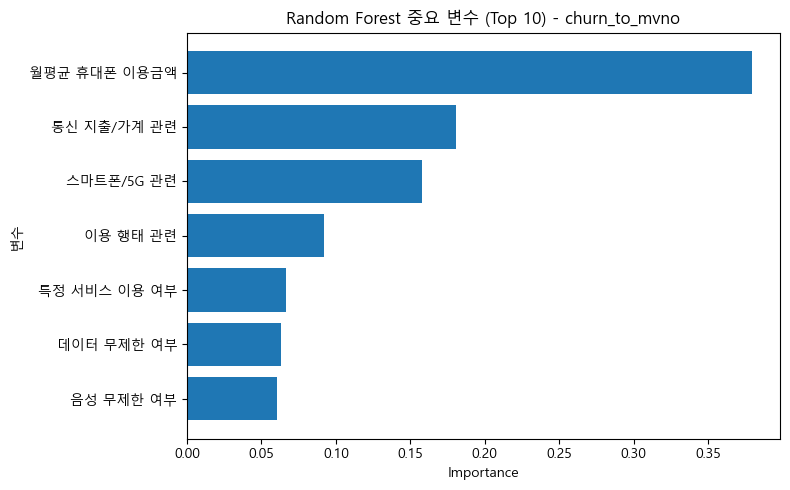

In [15]:
# ============================================================
# 13. 중요 변수 시각화
# ============================================================
top_n = 10
plot_df = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature_label"], plot_df["importance"])
plt.title("Random Forest 중요 변수 (Top 10) - churn_to_mvno")
plt.xlabel("Importance")
plt.ylabel("변수")
plt.tight_layout()
plt.show()


,threshold,precision,recall,f1
0,0.05,0.010112,1.000000,0.020021
1,0.10,0.010114,1.000000,0.020026
2,0.15,0.010158,1.000000,0.020113
3,0.20,0.010282,1.000000,0.020354
4,0.25,0.010567,1.000000,0.020914
5,0.30,0.010887,0.976190,0.021534
6,0.35,0.011365,0.928571,0.022456
7,0.40,0.012309,0.833333,0.024259
8,0.45,0.013277,0.714286,0.026070
9,0.50,0.013366,0.523810,0.026066


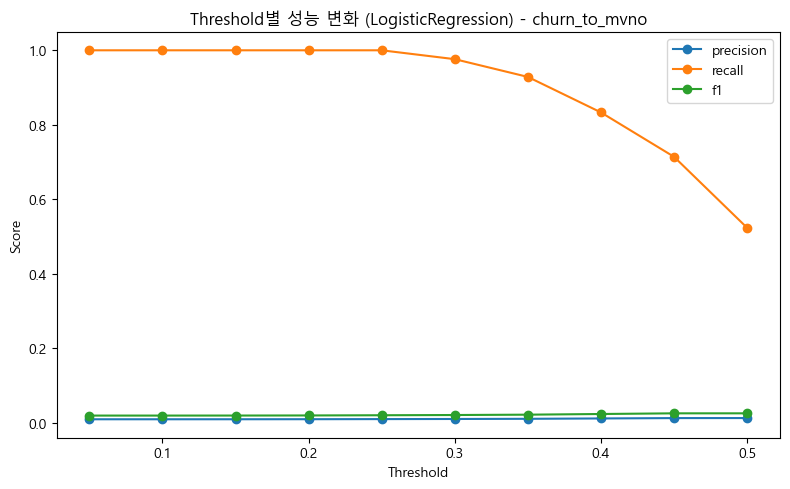

In [16]:
# ============================================================
# 추가. Logistic Regression threshold 조정
# ============================================================
def evaluate_by_threshold(y_true, y_proba, thresholds):
    rows = []
    for th in thresholds:
        y_pred = (y_proba >= th).astype(int)
        rows.append({
            "threshold": th,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)
        })
    return pd.DataFrame(rows)

thresholds = np.arange(0.05, 0.51, 0.05)
threshold_df = evaluate_by_threshold(y_test, y_proba_log, thresholds)

display(threshold_df)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="f1")
plt.title("Threshold별 성능 변화 (LogisticRegression) - churn_to_mvno")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()


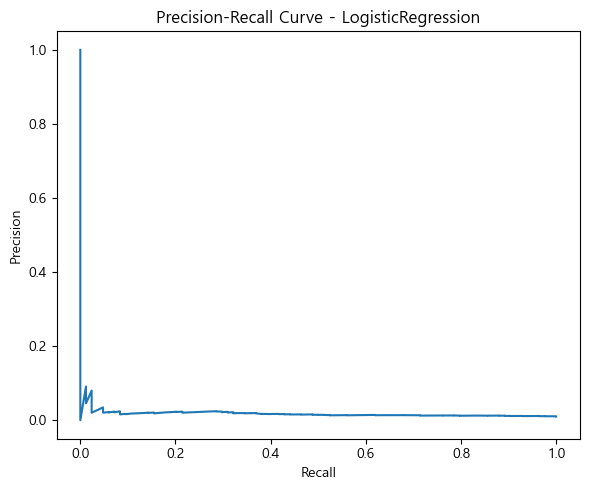

In [17]:
# ============================================================
# 추가. Precision-Recall Curve
# ============================================================
precision_arr, recall_arr, pr_thresholds = precision_recall_curve(y_test, y_proba_log)

plt.figure(figsize=(6, 5))
plt.plot(recall_arr, precision_arr)
plt.title("Precision-Recall Curve - LogisticRegression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()


In [18]:
# ============================================================
# 추가. XGBoost 중요도 확인
# ============================================================
xgb_model = xgb_pipe.named_steps["model"]

xgb_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
})

xgb_importance_df["feature_label"] = rename_feature_series(xgb_importance_df["feature"])
xgb_importance_df = xgb_importance_df.sort_values("importance", ascending=False)

xgb_importance_display_df = xgb_importance_df[["feature_label", "importance"]].copy()
xgb_importance_display_df.columns = ["변수", "중요도"]
display(xgb_importance_display_df.head(15))

,변수,중요도
3,월평균 휴대폰 이용금액,0.195415
6,이용 행태 관련,0.141327
0,스마트폰/5G 관련,0.135949
5,특정 서비스 이용 여부,0.134260
2,데이터 무제한 여부,0.133855
1,음성 무제한 여부,0.133265
4,통신 지출/가계 관련,0.125928


## [ 결과 해석 ]

### 1. `churn_to_mvno` baseline 모델 비교 해석

`churn_to_mvno`는 양성 비율이 약 `1.01%` 수준으로 매우 낮은 희소 클래스 문제다.
따라서 Accuracy보다 `Recall`, `F1`, `PR-AUC`를 중심으로 해석하는 것이 적절하다.

이번 비교 결과에서는 `DecisionTree`와 `LogisticRegression`이 실제 양성을 상대적으로 더 많이 탐지했다.

`DecisionTree`는 Recall `0.5476`, F1 `0.0282`를 기록하여 Recall과 F1 기준 가장 높은 성능을 보였다.

`LogisticRegression`도 Recall `0.5238`, F1 `0.0261`, ROC-AUC `0.6264`, PR-AUC `0.0182`로 나타나, 전체적으로 가장 안정적인 희소 클래스 baseline 모델로 해석할 수 있다.

반면 `RandomForest`는 Recall `0.2619`, F1 `0.0235` 수준으로 실제 양성 탐지 성능이 다소 낮았고, `GradientBoosting`과 `XGBoost`는 양성 예측을 거의 수행하지 않아 F1이 0에 가까웠다.

즉 이번 `churn_to_mvno` 문제에서는 복잡한 부스팅 계열 모델보다 `LogisticRegression`과 `DecisionTree`가 더 실질적인 baseline 역할을 수행했다고 볼 수 있다.

### 2. 희소 클래스와 threshold 해석

`LogisticRegression`의 threshold 결과를 보면, threshold를 낮게 둘수록 Recall은 크게 높아지지만 Precision은 매우 낮아졌다.

예를 들어
- threshold `0.30`에서는 Recall `0.9762`, F1 `0.0215`
- threshold `0.40`에서는 Recall `0.8333`, F1 `0.0243`
- threshold `0.45`에서는 Recall `0.7143`, F1 `0.0261`
- threshold `0.50`에서는 Recall `0.5238`, F1 `0.0261`

로 나타났다.

즉 이 문제에서는 threshold를 너무 높게 잡으면 실제 MVNO 이동자를 많이 놓치게 되고, 너무 낮게 잡으면 거의 모든 샘플을 양성으로 보는 수준이 되어 Precision이 급격히 악화된다.

이번 실험에서는 F1 기준으로 `0.45~0.50` 부근이 상대적으로 균형적이었고, 실제 운영 목적이 “놓치지 않는 탐지”라면 `0.40` 근처처럼 더 낮은 threshold도 고려할 수 있다.

즉 `churn_to_mvno`는 단순 0.5 기준만으로 판단하기보다 운영 목적에 맞게 threshold를 조정하는 것이 핵심인 문제로 해석할 수 있다.

### 3. 변수 해석

`LogisticRegression` 계수 기준으로는 `월평균 휴대폰 이용금액`의 절대값이 가장 크게 나타났고, `음성 무제한 여부`, `특정 서비스 이용 여부`, `스마트폰/5G 관련`도 상대적으로 영향력이 큰 변수로 확인되었다.

`RandomForest`와 `XGBoost` 중요도 모두에서도
- `월평균 휴대폰 이용금액`
- `통신 지출/가계 관련`
- `스마트폰/5G 관련`

이 상위권에 위치했다.

즉 메이저 통신사에서 알뜰폰으로 이동하는 행동 역시 비용 관련 변수와 서비스 이용 특성의 영향을 크게 받고 있다고 해석할 수 있다.